# Model Readiness

In [5]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')

current = Path.cwd()
while current.name != "credit_fraud_ml":
    current = current.parent
os.chdir(current)
sys.path.append(str(current))

from src.data.data_loader import DataLoader
from src.features.feature_engineering import FeatureEngineer

loader   = DataLoader()
data     = loader.load_all('train')
engineer = FeatureEngineer()
df       = engineer.fit_transform(**data)

print(f"\nFeature matrix: {df.shape}")
print(f"Fraud rate    : {df['TX_FRAUD'].mean()*100:.2f}%")

✓ Loaded 291,231 train transactions
✓ Loaded 1,000 customers
✓ Loaded 2,000 terminals
🔧 Feature Engineering Pipeline Starting...
   Input: 291,231 transactions
   ✓ Merged tables: (291231, 15)
   ✓ Temporal features (14)
   ✓ Geographic features (2)
   ✓ Amount deviation features (6)
   ✓ Terminal risk features (5) - YOUR TOP FEATURES!
   ✓ Customer behavioral features (3)
   ✓ Advanced contextual features (7)
   ✓ Interaction features (6)

✅ Complete: 57 features created!

Feature matrix: (291231, 57)
Fraud rate    : 2.26%


In [6]:
# ── Model Readiness: Feature Matrix Inspection ─────────────────────────────
DROP_COLS = ['TX_FRAUD', 'TRANSACTION_ID', 'TX_DATETIME', 'CUSTOMER_ID', 'TERMINAL_ID']

object_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Object columns to drop: {object_cols}")

X = df.drop(columns=DROP_COLS + object_cols, errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
y = df['TX_FRAUD']

print(f"\nFinal feature count : {X.shape[1]}")
print(f"Training samples    : {len(X):,}")
print(f"Fraud samples       : {y.sum():,}  ({y.mean()*100:.2f}%)")
X.describe().T[['mean','std','min','max']].head(10)

Object columns to drop: ['available_terminals']

Final feature count : 51
Training samples    : 291,231
Fraud samples       : 6,582  (2.26%)


,mean,std,min,max
TX_AMOUNT,53.182274,39.573329,0.000000,291.150000
x_customer_id,50.184880,28.732398,0.007245,99.994897
y_customer_id,50.429252,28.416998,0.036734,99.996402
mean_amount,51.710394,27.475610,5.063101,99.981815
std_amount,25.855197,13.737805,2.531550,49.990907
mean_nb_tx_per_day,2.650934,0.961907,0.018782,3.999725
nb_terminals,15.300318,4.190001,2.000000,28.000000
x_terminal_id,50.218904,28.682009,0.011437,99.859909
y_terminal_id,50.392889,28.376333,0.009695,99.987579
tx_hour,11.507707,5.059829,0.000000,23.000000


In [7]:
# ── Train / Validation Split + Scaling ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

neg, pos  = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}")
print(f"Class imbalance ratio (neg/pos): {scale_pos:.1f}x")

Train : 232,984  |  Val : 58,247
Class imbalance ratio (neg/pos): 43.2x


In [8]:
# ── Train Classical Models (RF, XGBoost, LightGBM) ─────────────────────────
from src.models.train import train_random_forest, train_xgboost, train_lightgbm

classical_models = {}
classical_times  = {}

for name, trainer in [
    ('Random Forest', train_random_forest),
    ('XGBoost',       train_xgboost),
    ('LightGBM',      train_lightgbm),
]:
    t0 = time.time()
    classical_models[name] = trainer(X_train, y_train)
    classical_times[name]  = time.time() - t0
    print(f"  {name} trained in {classical_times[name]:.1f}s")


 Training Random Forest...
  Random Forest trained in 9.2s

 Training XGBoost...
  XGBoost trained in 1.5s

⚡ Training LightGBM...
[LightGBM] [Info] Number of positive: 5266, number of negative: 227718
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6368
[LightGBM] [Info] Number of data points in the train set: 232984, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.022602 -> initscore=-3.766837
[LightGBM] [Info] Start training from score -3.766837
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM

In [9]:
# ── Neural Network (Keras MLP) ──────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)

n_features = X_train_s.shape[1]

def build_mlp(n_features, scale_pos_weight):
    inp = keras.Input(shape=(n_features,))
    x   = layers.Dense(256, activation='relu')(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.3)(x)
    x   = layers.Dense(64,  activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(1,   activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

nn_model = build_mlp(n_features, scale_pos)
nn_model.summary()

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
)

t0 = time.time()
history = nn_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=50,
    batch_size=2048,
    class_weight={0: 1.0, 1: scale_pos},
    callbacks=[early_stop],
    verbose=1
)
nn_time = time.time() - t0
print(f"\nNeural Network trained in {nn_time:.1f}s")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 51)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,065 (219.00 KB)

 Trainable params: 55,297 (216.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.7375 - loss: 1.2385 - val_auc: 0.8423 - val_loss: 0.4660
Epoch 2/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8326 - loss: 0.9841 - val_auc: 0.8621 - val_loss: 0.4061
Epoch 3/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8574 - loss: 0.9142 - val_auc: 0.8730 - val_loss: 0.3917
Epoch 4/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8709 - loss: 0.8764 - val_auc: 0.8811 - val_loss: 0.4127
Epoch 5/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8803 - loss: 0.8456 - val_auc: 0.8852 - val_loss: 0.4175
Epoch 6/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8818 - loss: 0.8389 - val_auc: 0.8855 - val_loss: 0.4075
Epoch 7/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.8877 - loss: 0.8174 - val_auc: 0.8874 - val_loss: 0.4100
Epoch 8/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - auc: 0.8905 - loss: 0.8077 - val_auc: 0.8901 - val_loss: 0.4034
Epoch 9/50
114/114 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - au

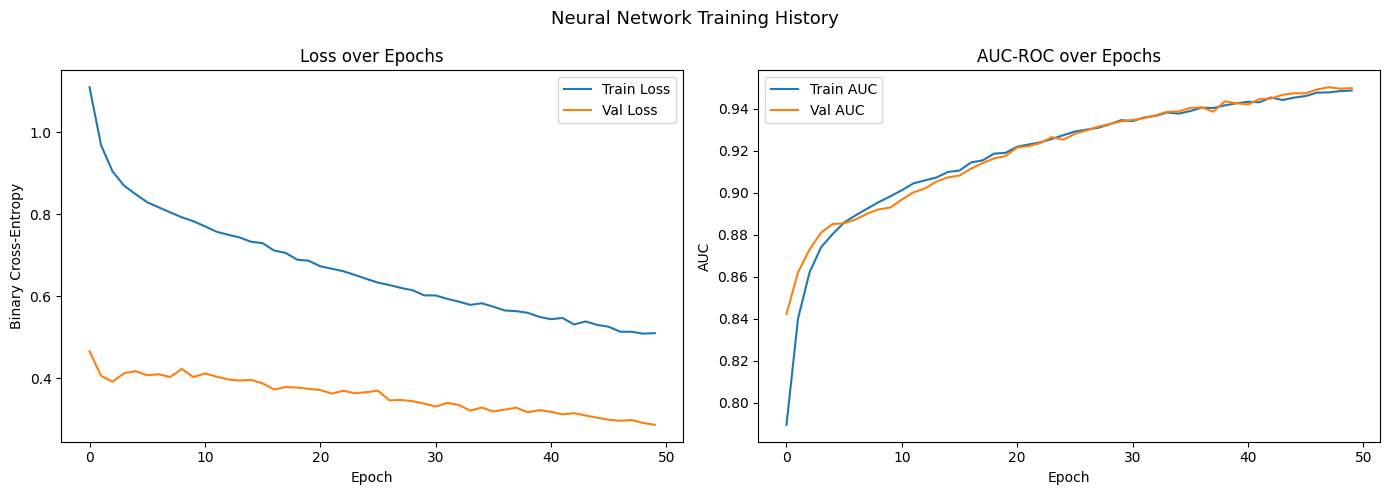

In [10]:
# ── Neural Network Training History ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC-ROC over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Neural Network Training History', fontsize=13)
plt.tight_layout()
plt.show()

In [11]:
# ── Evaluate All Models ─────────────────────────────────────────────────────
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, classification_report
)

def get_metrics(name, y_true, y_pred, y_proba, train_time=0):
    return {
        'Model'     : name,
        'Precision' : precision_score(y_true, y_pred),
        'Recall'    : recall_score(y_true, y_pred),
        'F1'        : f1_score(y_true, y_pred),
        'ROC-AUC'   : roc_auc_score(y_true, y_proba),
        'Train time': f'{train_time:.1f}s',
    }

results    = []
all_probas = {}

# Classical models use raw (unscaled) features
for name, model in classical_models.items():
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= 0.5).astype(int)
    results.append(get_metrics(name, y_val, y_pred, y_proba, classical_times[name]))
    all_probas[name] = y_proba

# Neural network uses scaled features
nn_proba = nn_model.predict(X_val_s, verbose=0).flatten()
nn_pred  = (nn_proba >= 0.5).astype(int)
results.append(get_metrics('Neural Network (MLP)', y_val, nn_pred, nn_proba, nn_time))
all_probas['Neural Network (MLP)'] = nn_proba

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.to_string())
results_df

                      Precision    Recall        F1   ROC-AUC Train time
Model                                                                   
Random Forest          0.160103  0.710486  0.261319  0.908545       9.2s
XGBoost                0.821429  0.069909  0.128852  0.951752       1.5s
LightGBM               0.831776  0.067629  0.125088  0.942543       1.8s
Neural Network (MLP)   0.131886  0.936930  0.231224  0.950957      32.1s


,Precision,Recall,F1,ROC-AUC,Train time
Model,,,,,
Random Forest,0.160103,0.710486,0.261319,0.908545,9.2s
XGBoost,0.821429,0.069909,0.128852,0.951752,1.5s
LightGBM,0.831776,0.067629,0.125088,0.942543,1.8s
Neural Network (MLP),0.131886,0.936930,0.231224,0.950957,32.1s


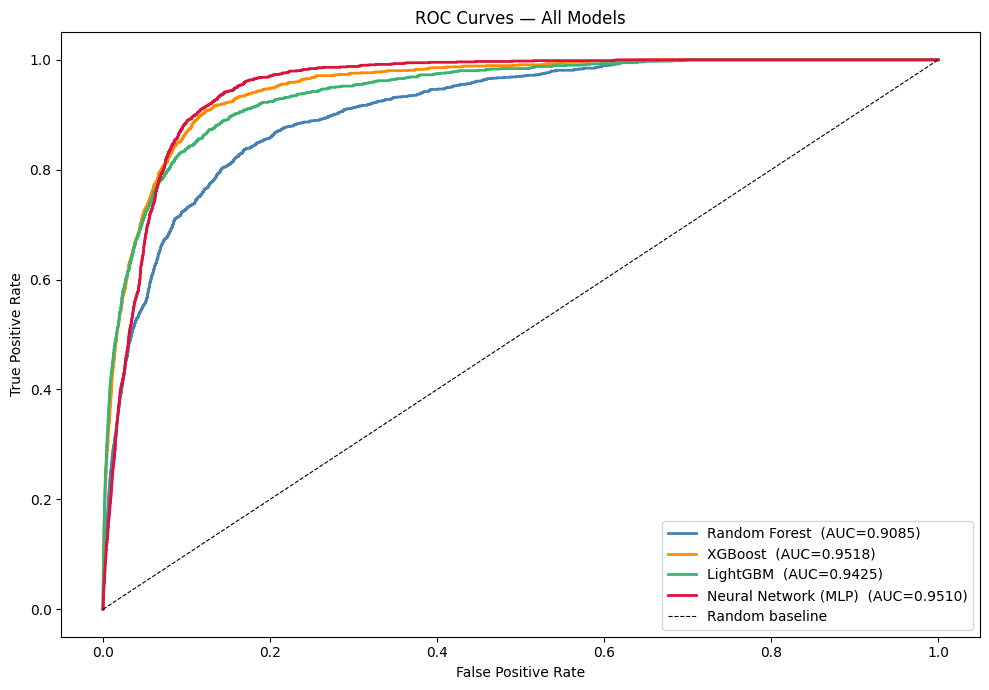

In [12]:
# ── ROC Curves: All Models ──────────────────────────────────────────────────
plt.figure(figsize=(10, 7))

colors = ['steelblue', 'darkorange', 'mediumseagreen', 'crimson']
for (name, proba), color in zip(all_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

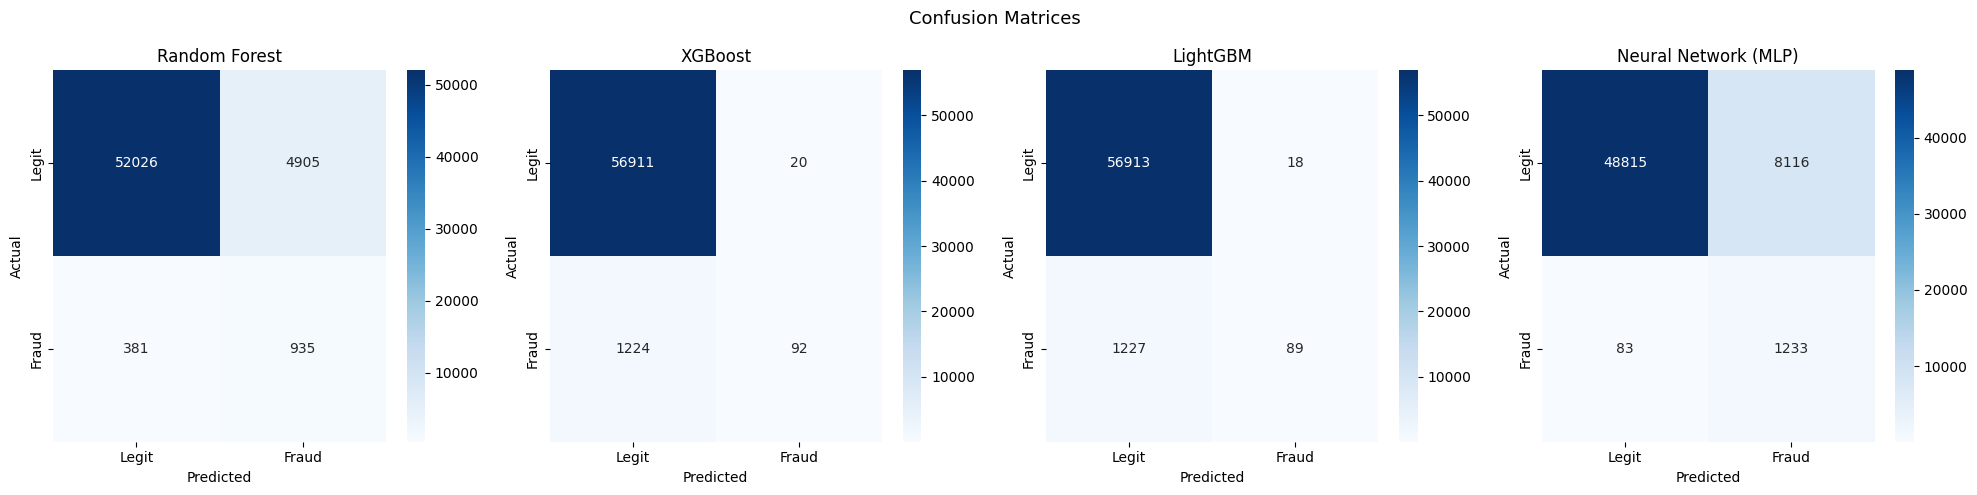

In [13]:
# ── Confusion Matrices: All Models ─────────────────────────────────────────
all_preds = {}
for name, model in classical_models.items():
    all_preds[name] = (model.predict_proba(X_val)[:, 1] >= 0.5).astype(int)
all_preds['Neural Network (MLP)'] = nn_pred

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (name, y_pred) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'],
                yticklabels=['Legit', 'Fraud'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.show()

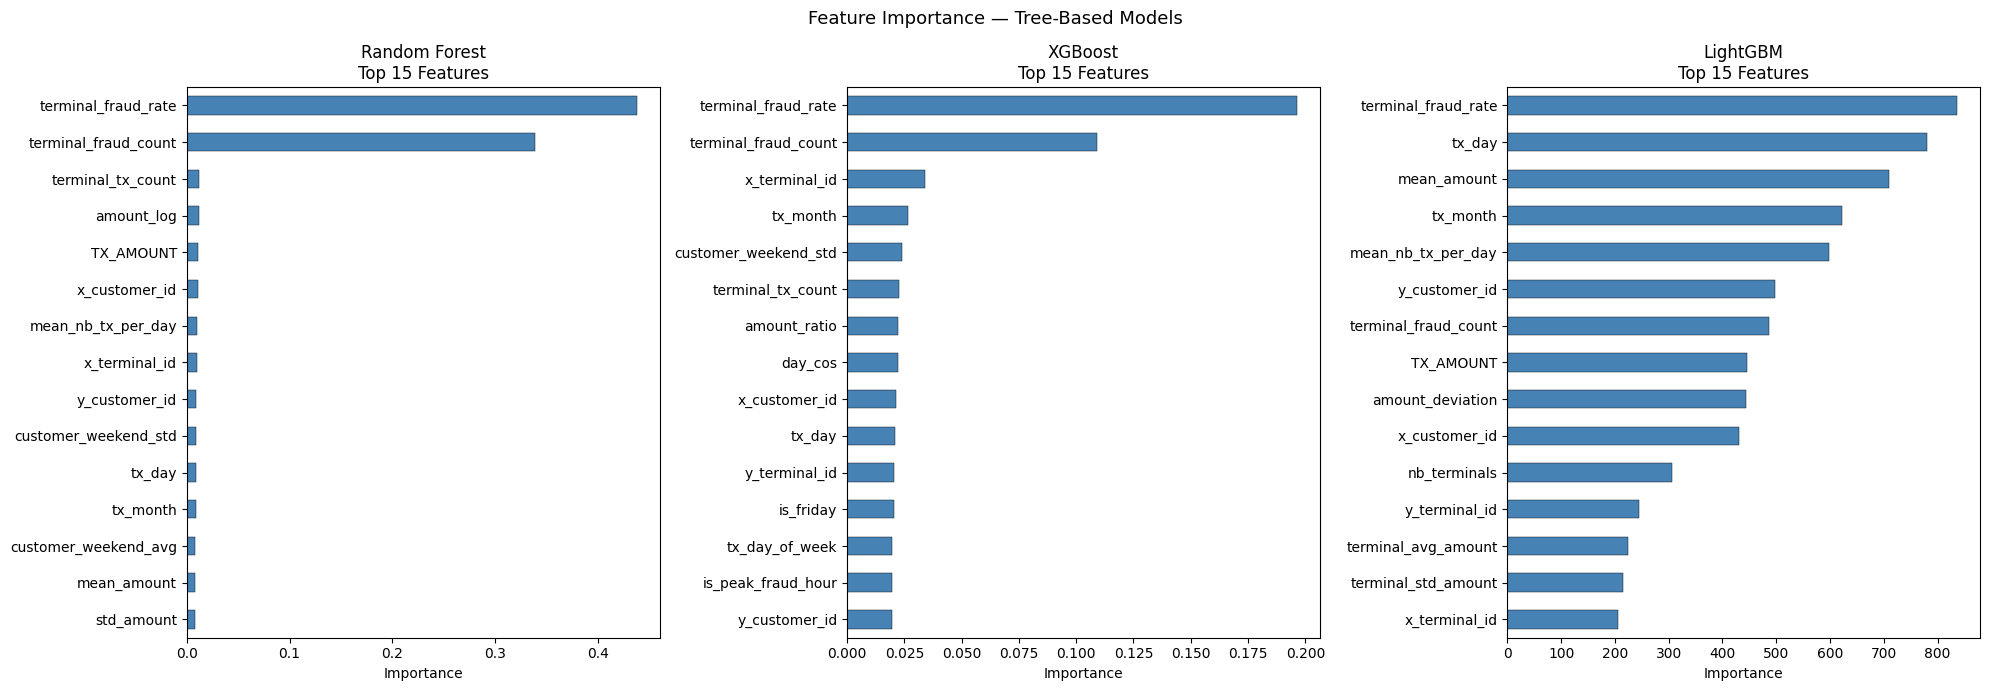

In [14]:
# ── Feature Importance (Tree Models) ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (name, model) in zip(axes, classical_models.items()):
    imp = pd.Series(model.feature_importances_, index=X.columns)
    top = imp.nlargest(15).sort_values()
    top.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', linewidth=0.3)
    ax.set_title(f'{name}\nTop 15 Features')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance — Tree-Based Models', fontsize=13)
plt.tight_layout()
plt.show()

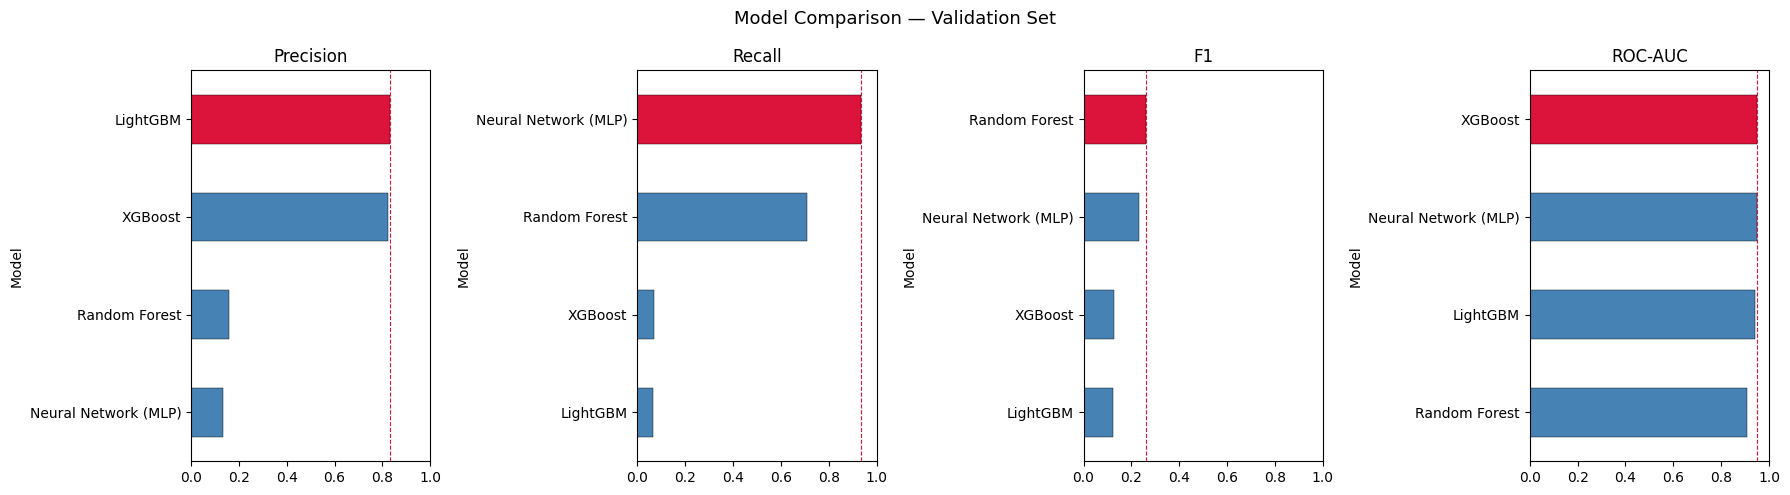


=== Final Leaderboard ===
                      Precision    Recall        F1   ROC-AUC
Model                                                        
XGBoost                0.821429  0.069909  0.128852  0.951752
Neural Network (MLP)   0.131886  0.936930  0.231224  0.950957
LightGBM               0.831776  0.067629  0.125088  0.942543
Random Forest          0.160103  0.710486  0.261319  0.908545


In [15]:
# ── Final Model Comparison Summary ─────────────────────────────────────────
numeric_cols = ['Precision', 'Recall', 'F1', 'ROC-AUC']
summary = results_df[numeric_cols].copy()

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, metric in zip(axes, numeric_cols):
    vals   = summary[metric].sort_values(ascending=True)
    colors = ['crimson' if v == vals.max() else 'steelblue' for v in vals]
    vals.plot(kind='barh', ax=ax, color=colors, edgecolor='black', linewidth=0.3)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.axvline(vals.max(), color='crimson', linestyle='--', linewidth=0.8)

plt.suptitle('Model Comparison — Validation Set', fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== Final Leaderboard ===")
print(results_df[numeric_cols].sort_values('ROC-AUC', ascending=False).to_string())